In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv('/kaggle/input/tcs-stock-history/TCS_stock_history.csv')
df

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2002-08-12,28.794172,29.742206,28.794172,29.519140,212976,0.0,0.0
1,2002-08-13,29.556316,30.030333,28.905705,29.119476,153576,0.0,0.0
2,2002-08-14,29.184536,29.184536,26.563503,27.111877,822776,0.0,0.0
3,2002-08-15,27.111877,27.111877,27.111877,27.111877,0,0.0,0.0
4,2002-08-16,26.972458,28.255089,26.582090,27.046812,811856,0.0,0.0
...,...,...,...,...,...,...,...,...
4458,2021-09-24,3890.000000,3944.399902,3855.000000,3871.300049,2320754,0.0,0.0
4459,2021-09-27,3900.000000,3904.000000,3802.899902,3836.949951,1673362,0.0,0.0
4460,2021-09-28,3850.000000,3850.000000,3751.250000,3779.149902,2253075,0.0,0.0
4461,2021-09-29,3759.800049,3806.000000,3722.149902,3791.899902,2489161,0.0,0.0


In [4]:
df.isnull().sum()

Date            0
Open            0
High            0
Low             0
Close           0
Volume          0
Dividends       0
Stock Splits    0
dtype: int64

In [5]:
df.duplicated().sum()

0

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4463 entries, 0 to 4462
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          4463 non-null   object 
 1   Open          4463 non-null   float64
 2   High          4463 non-null   float64
 3   Low           4463 non-null   float64
 4   Close         4463 non-null   float64
 5   Volume        4463 non-null   int64  
 6   Dividends     4463 non-null   float64
 7   Stock Splits  4463 non-null   float64
dtypes: float64(6), int64(1), object(1)
memory usage: 279.1+ KB


In [7]:
df.describe()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,4463.000000,4463.000000,4463.000000,4463.000000,4.463000e+03,4463.000000,4463.000000
mean,866.936239,876.675013,856.653850,866.537398,3.537876e+06,0.071533,0.001344
std,829.905368,838.267104,821.233477,829.611313,3.273531e+06,0.965401,0.051842
min,24.146938,27.102587,24.146938,26.377609,0.000000e+00,0.000000,0.000000
25%,188.951782,191.571816,185.979417,188.594620,1.860959e+06,0.000000,0.000000
50%,530.907530,534.751639,525.616849,529.713257,2.757742e+06,0.000000,0.000000
75%,1156.462421,1165.815854,1143.622800,1154.784851,4.278625e+06,0.000000,0.000000
max,3930.000000,3981.750000,3892.100098,3954.550049,8.806715e+07,40.000000,2.000000


In [8]:
df['Date'] = pd.to_datetime(df['Date'])

In [11]:
df['year'] = df['Date'].dt.year

In [10]:
df['Month'] = df['Date'].dt.month

In [12]:
df['Day'] = df['Date'].dt.day

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4463 entries, 0 to 4462
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          4463 non-null   datetime64[ns]
 1   Open          4463 non-null   float64       
 2   High          4463 non-null   float64       
 3   Low           4463 non-null   float64       
 4   Close         4463 non-null   float64       
 5   Volume        4463 non-null   int64         
 6   Dividends     4463 non-null   float64       
 7   Stock Splits  4463 non-null   float64       
 8   Month         4463 non-null   int32         
 9   year          4463 non-null   int32         
 10  Day           4463 non-null   int32         
dtypes: datetime64[ns](1), float64(6), int32(3), int64(1)
memory usage: 331.4 KB


In [14]:
df.drop(columns= 'Date',inplace = True)

In [15]:
df

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Month,year,Day
0,28.794172,29.742206,28.794172,29.519140,212976,0.0,0.0,8,2002,12
1,29.556316,30.030333,28.905705,29.119476,153576,0.0,0.0,8,2002,13
2,29.184536,29.184536,26.563503,27.111877,822776,0.0,0.0,8,2002,14
3,27.111877,27.111877,27.111877,27.111877,0,0.0,0.0,8,2002,15
4,26.972458,28.255089,26.582090,27.046812,811856,0.0,0.0,8,2002,16
...,...,...,...,...,...,...,...,...,...,...
4458,3890.000000,3944.399902,3855.000000,3871.300049,2320754,0.0,0.0,9,2021,24
4459,3900.000000,3904.000000,3802.899902,3836.949951,1673362,0.0,0.0,9,2021,27
4460,3850.000000,3850.000000,3751.250000,3779.149902,2253075,0.0,0.0,9,2021,28
4461,3759.800049,3806.000000,3722.149902,3791.899902,2489161,0.0,0.0,9,2021,29


In [16]:
df.columns

Index(['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits',
       'Month', 'year', 'Day'],
      dtype='object')

Open


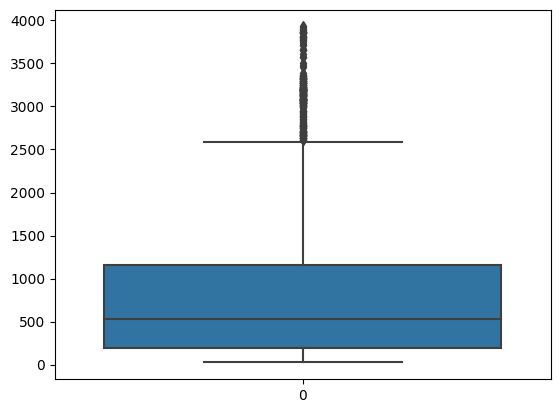

High


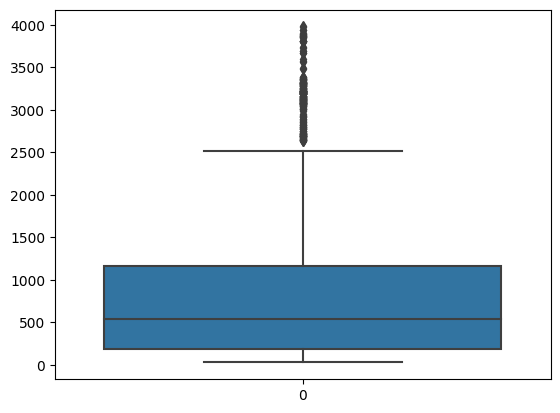

Low


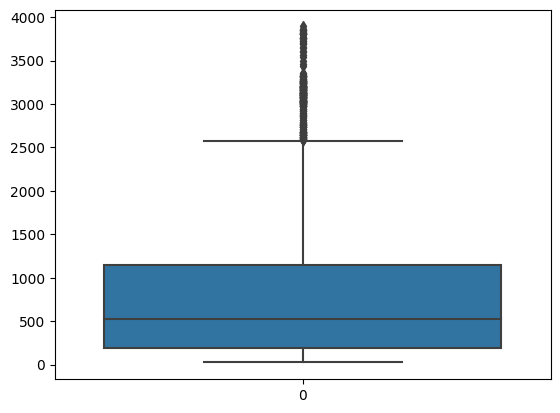

Close


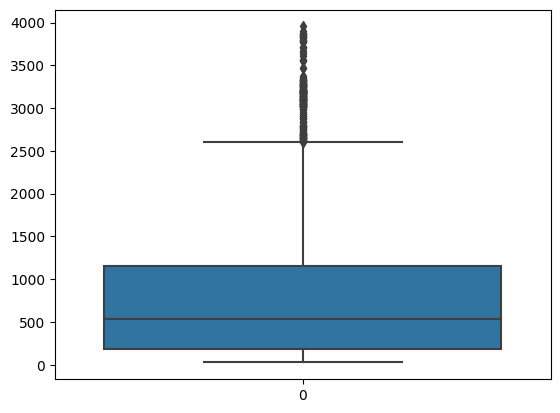

Volume


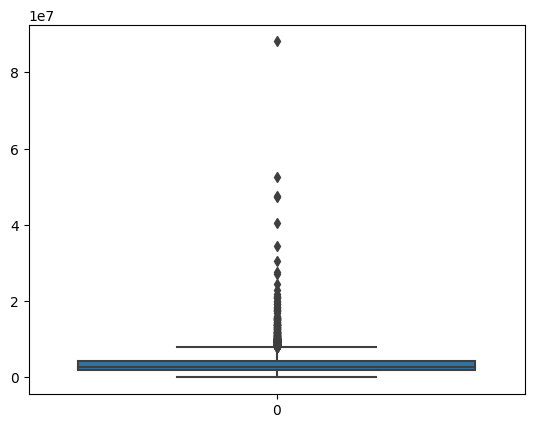

In [17]:
columns=['Open', 'High', 'Low', 'Close', 'Volume']
for i in columns:
    print(i)
    sns.boxplot(df[i])
    plt.show()

In [18]:
continous_features = ['Open', 'High', 'Low', 'Close', 'Volume']  
def outliers(df, drop = False):
    for each_feature in df.columns:
        feature_data = df[each_feature]
        Q1 = np.percentile(feature_data, 25.) # 25th percentile of the data of the given feature
        Q3 = np.percentile(feature_data, 75.) # 75th percentile of the data of the given feature
        IQR = Q3-Q1 #Interquartile Range
        outlier_step = IQR * 1.5 #That's we were talking about above
        outliers = feature_data[~((feature_data >= Q1 - outlier_step) & (feature_data <= Q3 + outlier_step))].index.tolist()  
        if not drop:
            print('For the feature {}, No of Outliers is {}'.format(each_feature, len(outliers)))
        if drop:
            df.drop(outliers, inplace = True, errors = 'ignore')
            print('Outliers from {} feature removed'.format(each_feature))

outliers(df[continous_features])

For the feature Open, No of Outliers is 242
For the feature High, No of Outliers is 246
For the feature Low, No of Outliers is 242
For the feature Close, No of Outliers is 243
For the feature Volume, No of Outliers is 282


In [19]:
 outliers(df[continous_features],drop=True)

Outliers from Open feature removed
Outliers from High feature removed
Outliers from Low feature removed
Outliers from Close feature removed
Outliers from Volume feature removed


Open


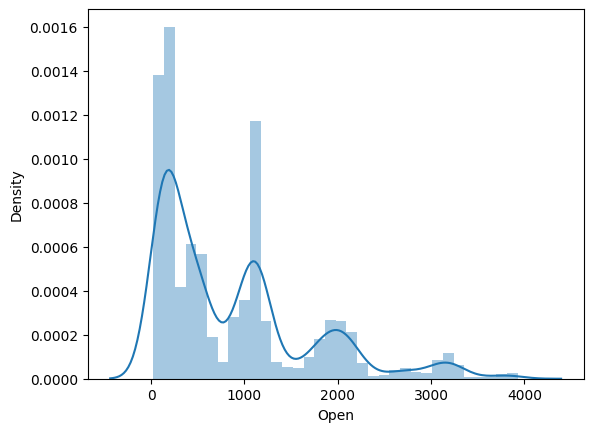

High


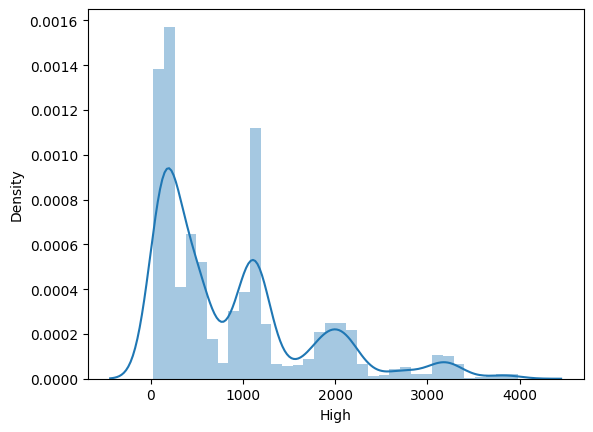

Low


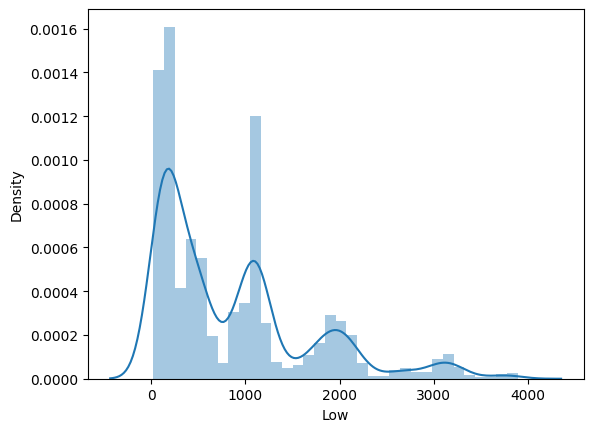

Close


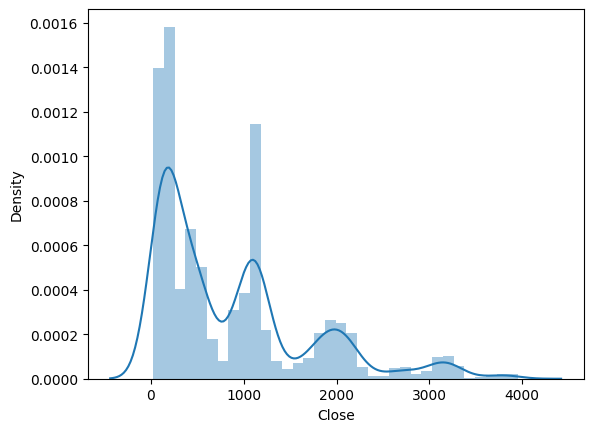

Volume


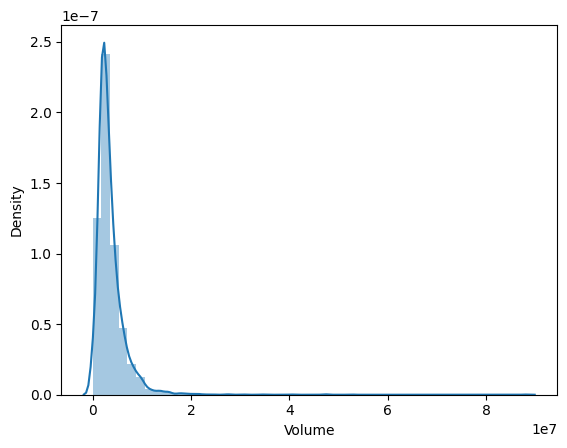

In [20]:
columns=['Open', 'High', 'Low', 'Close', 'Volume']
for i in columns:
    print(i)
    sns.distplot(df[i])
    plt.show()

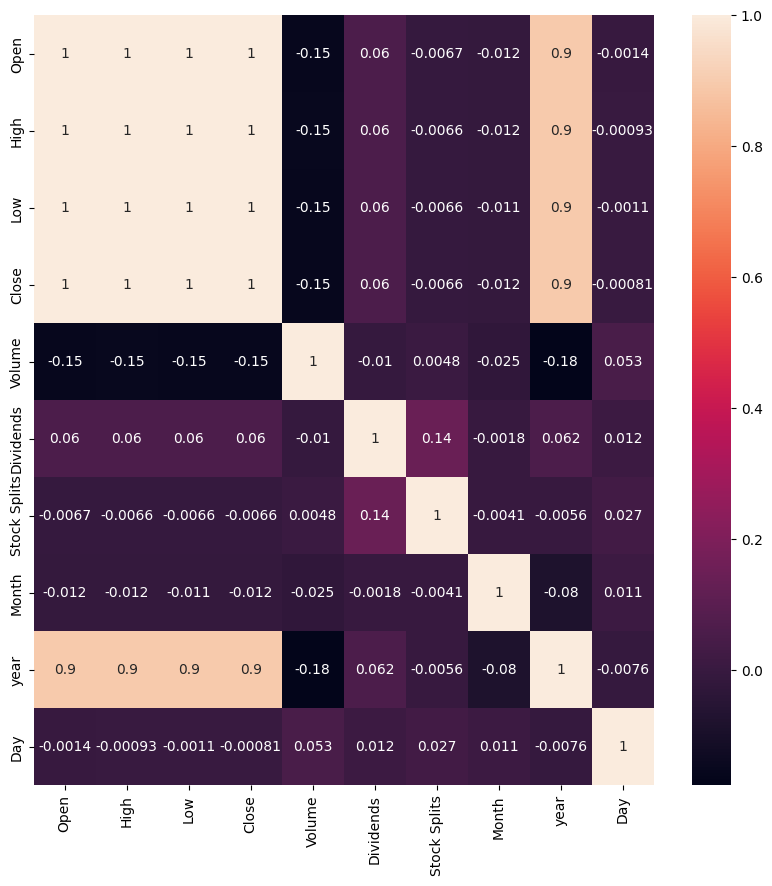

In [21]:
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(),annot = True)
plt.show()

In [22]:
df

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Month,year,Day
0,28.794172,29.742206,28.794172,29.519140,212976,0.0,0.0,8,2002,12
1,29.556316,30.030333,28.905705,29.119476,153576,0.0,0.0,8,2002,13
2,29.184536,29.184536,26.563503,27.111877,822776,0.0,0.0,8,2002,14
3,27.111877,27.111877,27.111877,27.111877,0,0.0,0.0,8,2002,15
4,26.972458,28.255089,26.582090,27.046812,811856,0.0,0.0,8,2002,16
...,...,...,...,...,...,...,...,...,...,...
4458,3890.000000,3944.399902,3855.000000,3871.300049,2320754,0.0,0.0,9,2021,24
4459,3900.000000,3904.000000,3802.899902,3836.949951,1673362,0.0,0.0,9,2021,27
4460,3850.000000,3850.000000,3751.250000,3779.149902,2253075,0.0,0.0,9,2021,28
4461,3759.800049,3806.000000,3722.149902,3791.899902,2489161,0.0,0.0,9,2021,29


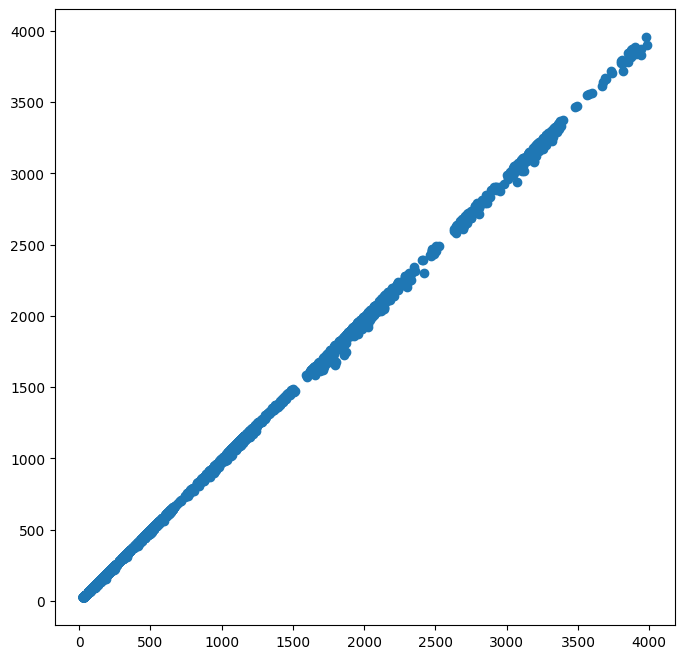

In [23]:
plt.figure(figsize=(8,8))
plt.scatter(df['High'],df['Close'])
plt.show()

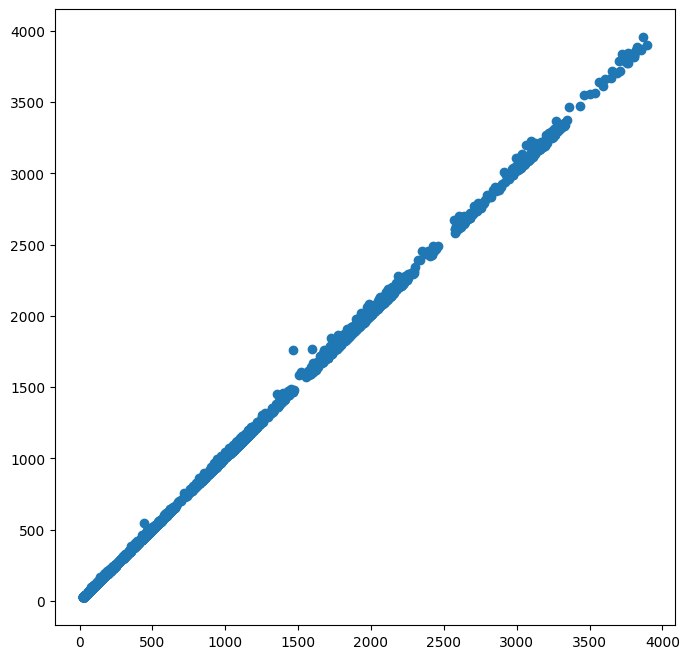

In [24]:
plt.figure(figsize=(8,8))
plt.scatter(df['Low'],df['Close'])
plt.show()

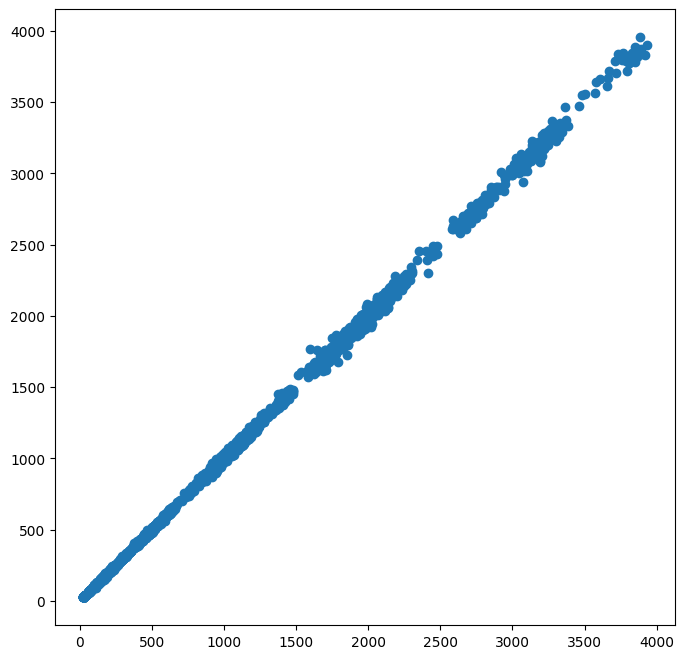

In [25]:
plt.figure(figsize=(8,8))
plt.scatter(df['Open'],df['Close'])
plt.show()

In [26]:
target =df['Close']
target

0         29.519140
1         29.119476
2         27.111877
3         27.111877
4         27.046812
           ...     
4458    3871.300049
4459    3836.949951
4460    3779.149902
4461    3791.899902
4462    3773.199951
Name: Close, Length: 4463, dtype: float64

In [27]:
df.drop(columns='Close')

,Open,High,Low,Volume,Dividends,Stock Splits,Month,year,Day
0,28.794172,29.742206,28.794172,212976,0.0,0.0,8,2002,12
1,29.556316,30.030333,28.905705,153576,0.0,0.0,8,2002,13
2,29.184536,29.184536,26.563503,822776,0.0,0.0,8,2002,14
3,27.111877,27.111877,27.111877,0,0.0,0.0,8,2002,15
4,26.972458,28.255089,26.582090,811856,0.0,0.0,8,2002,16
...,...,...,...,...,...,...,...,...,...
4458,3890.000000,3944.399902,3855.000000,2320754,0.0,0.0,9,2021,24
4459,3900.000000,3904.000000,3802.899902,1673362,0.0,0.0,9,2021,27
4460,3850.000000,3850.000000,3751.250000,2253075,0.0,0.0,9,2021,28
4461,3759.800049,3806.000000,3722.149902,2489161,0.0,0.0,9,2021,29


Linear Regression Model

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [29]:
X_train, X_test, y_train, y_test = train_test_split(df, target, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the Linear Regression model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Make predictions
y_pred = model.predict(X_test_scaled)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared Score: {r2}")


Mean Squared Error: 1.9079984547025218e-25
R-squared Score: 1.0


In [30]:
print("Linear Regression:")
print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_)

Linear Regression:
Intercept: 874.7768556146061
Coefficient: [-1.61744453e-12  1.87583282e-12  5.96855898e-13  8.33676791e+02
  1.49213975e-13  7.46069873e-14 -7.17204074e-14  1.62536651e-13
  1.42108547e-13 -8.16846590e-14]
